# **A Hybrid Machine Learning Approach for American Option Pricing**

## Part 1: Pipeline Development and Analysis**

This project presents a hybrid financial machine learning pipeline to efficiently approximate American option prices. By combining the Black-Scholes analytical model with machine learning techniques, the approach aims to reduce computational complexity while maintaining high pricing accuracy.

The core idea is to leverage financial theory as a structural foundation and allow machine learning models to capture only the complex residual component arising from early exercise features.


## **Problem Statement**

Pricing American options is computationally expensive due to the early exercise feature. Traditional methods like the CRR binomial tree are accurate but slow.

Machine learning models can approximate pricing, but directly predicting option prices is difficult due to the complex and non-linear structure.

To solve this, we use a hybrid approach that combines analytical pricing with machine learning.

---
## Cell 1 — Install & Import All Libraries

In [1]:
# Install all required packages
!pip install xgboost scipy scikit-learn scikit-optimize pandas numpy matplotlib seaborn torch torchvision tensorflow -q

# ── Standard ──
import numpy as np
import pandas as pd
import scipy.stats as si
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

# ── Scikit-learn ──
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# ── XGBoost ──
import xgboost as xgb

# ── TensorFlow / Keras ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f'TensorFlow version: {tf.__version__}')

# ── PyTorch ──
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
print(f'PyTorch version: {torch.__version__}')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print('✅ All libraries loaded!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00
TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cpu
✅ All libraries loaded!


## **Context and Approach**

American options are difficult to price due to the possibility of early exercise.

Traditional methods such as the CRR binomial tree are accurate but computationally expensive. Pure machine learning models also struggle because option pricing functions are highly non-linear.

To address this, we use a hybrid approach:
- Black-Scholes provides a baseline price
- Machine learning predicts only the residual (EEP)

This reduces the complexity of the learning problem.

---
## Cell 2 — Load Class Dataset

## **Load the Class Dataset**

**📌 Simple explanation:** We are loading 31,173 option prices. Each row is one option contract.
The `Amercall` column is the correct price — calculated using a very precise 15,000-step Binomial Tree.
Our ML models will try to learn to predict this price.

**Columns:**
- `S` = Current stock price
- `X` = Strike price (always 100 in this dataset)
- `T` = Time to expiry in years
- `r` = Risk-free interest rate
- `div` = Dividend yield
- `v` = Volatility (sigma)
- `n` = Number of binomial tree steps (15,000)
- `Amercall` = American call option price (our target)

In [2]:
# Upload american_call_option.csv to Colab before running
df = pd.read_csv('american_call_option.csv')

# Drop constant columns (X=100, n=15000 are always the same)
const_cols = [c for c in df.columns
              if df[c].nunique() <= 1
              and c not in ['S','X','T','r','div','v','Amercall']]
df = df.drop(columns=const_cols)

print(f'Dataset shape:   {df.shape}')
print(f'Columns:         {df.columns.tolist()}')
print(f'Missing values:  {df.isnull().sum().sum()}')
display(df.head())
display(df.describe().round(4))

Dataset shape:   (31173, 7)
Columns:         ['S', 'X', 'T', 'r', 'div', 'v', 'Amercall']
Missing values:  0


,S,X,T,r,div,v,Amercall
0,91.850064,100,0.754349,0.073504,0.039149,0.466568,12.199666
1,125.318545,100,0.233275,0.032105,0.097830,0.511820,26.909800
2,80.577346,100,4.249918,0.053841,0.073773,0.505688,20.475375
3,84.656262,100,0.361553,0.053248,0.086968,0.310740,1.530428
4,72.888120,100,0.479781,0.037619,0.009449,0.436926,2.111835


,S,X,T,r,div,v,Amercall
count,31173.0000,31173.0,31173.0000,31173.0000,31173.0000,31173.0000,31173.0000
mean,100.0766,100.0,1.1521,0.0398,0.0497,0.3497,14.8062
std,17.3511,0.0,1.2190,0.0325,0.0289,0.1447,11.9648
min,70.0040,100.0,0.1000,0.0000,0.0000,0.1000,0.0000
25%,85.0070,100.0,0.3993,0.0062,0.0247,0.2227,4.3642
50%,100.1841,100.0,0.6957,0.0372,0.0494,0.3505,12.7672
75%,115.1716,100.0,0.9955,0.0683,0.0748,0.4746,23.4338
max,129.9985,100.0,4.9992,0.1000,0.1000,0.6000,77.7353


## **Data Understanding**

We inspect the dataset structure to verify:
- Column names
- Data types
- Missing values

This ensures the dataset is clean and ready for modeling.

## **Stratified Sampling (10%)**

31,173 rows is a lot. We take 10% (~3,117 rows) but we make sure
we pick fairly from each group (cheap options, medium options, expensive options) This is called **stratified sampling**

In [3]:
# Stratified by moneyness bins — preserves distribution across ITM/ATM/OTM
df['moneyness_bin'] = pd.cut(df['S'] / df['X'], bins=5, labels=False)
df_sample = df.groupby('moneyness_bin', group_keys=False).apply(
    lambda x: x.sample(frac=0.10, random_state=RANDOM_STATE)
).reset_index(drop=True)
df_sample = df_sample.drop(columns=['moneyness_bin'])

print(f'Original: {len(df):,} rows → Sampled: {len(df_sample):,} rows (10%)')
print(f'Mean S/X original: {(df["S"]/df["X"]).mean():.4f}')
print(f'Mean S/X sample:   {(df_sample["S"]/df_sample["X"]).mean():.4f} (similar = stratification worked)')

df_sample.to_csv('american_call_option_sampled.csv', index=False)
print('✅ Sampled dataset saved!')

Original: 31,173 rows → Sampled: 3,116 rows (10%)
Mean S/X original: 1.0008
Mean S/X sample:   1.0016 (similar = stratification worked)
✅ Sampled dataset saved!


## **Exploratory Data Analysis (EDA)**

Before we build any model, we look at the data.
We want to understand: What does the data look like? Are there any weird values?

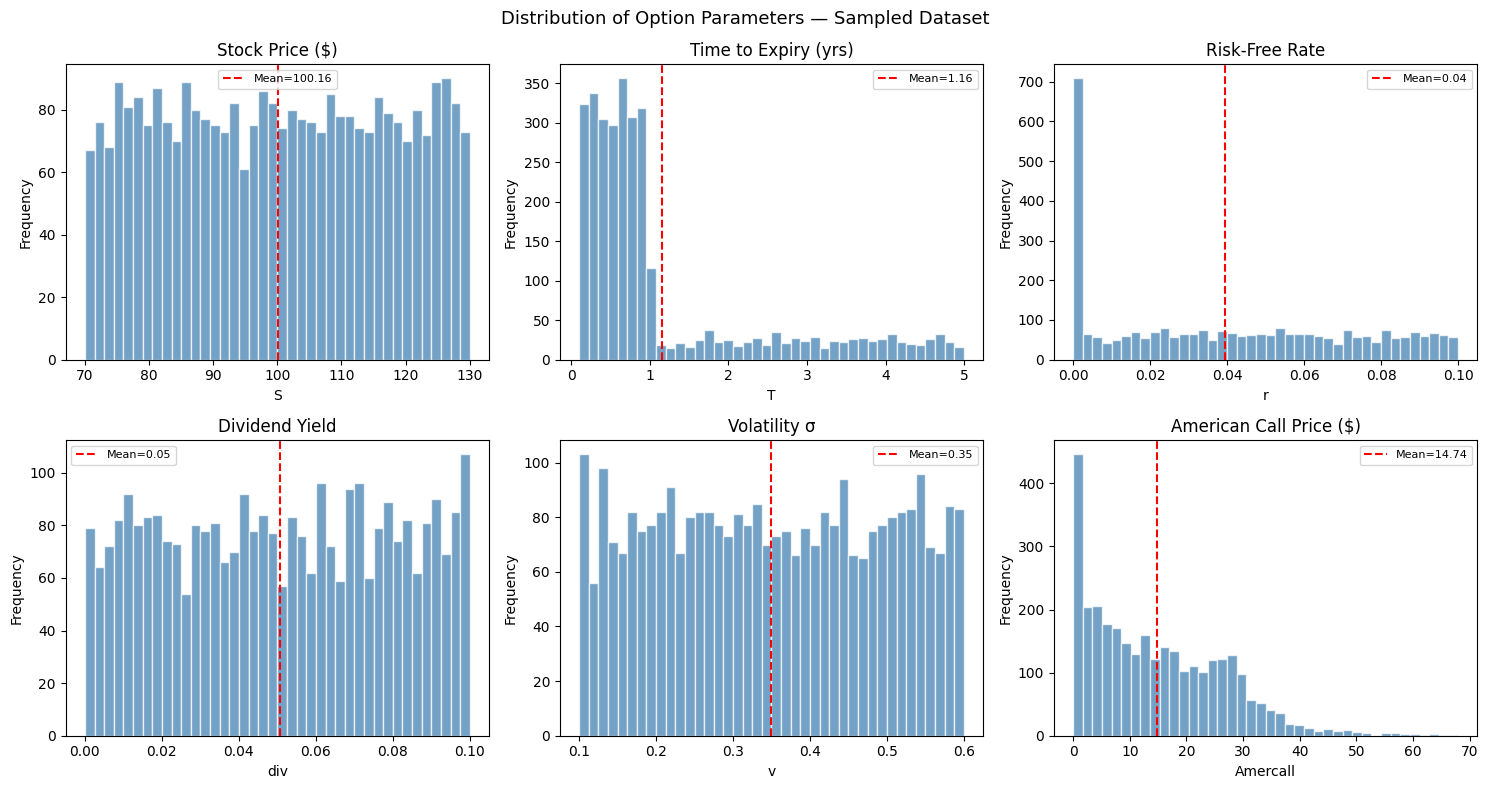

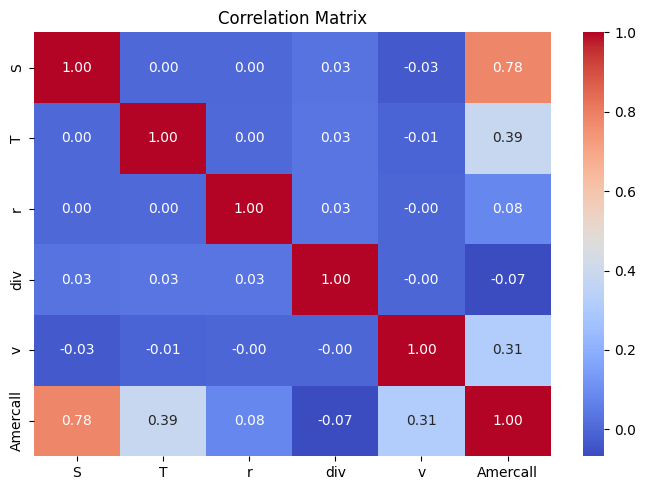

✅ EDA plots saved!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Option Parameters — Sampled Dataset', fontsize=13)

params = [('S','Stock Price ($)'),('T','Time to Expiry (yrs)'),
          ('r','Risk-Free Rate'),('div','Dividend Yield'),
          ('v','Volatility σ'),('Amercall','American Call Price ($)')]

for ax, (col, label) in zip(axes.flat, params):
    ax.hist(df_sample[col], bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(df_sample[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean={df_sample[col].mean():.2f}')
    ax.set_title(label); ax.set_xlabel(col); ax.set_ylabel('Frequency'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.heatmap(df_sample[['S','T','r','div','v','Amercall']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax2)
ax2.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()
print('✅ EDA plots saved!')

##**Black-Scholes Structural Prior & EEP Residual**

**Mathematical decomposition:**

$$C_{American} = \underbrace{C_{BlackScholes}}_{\text{We calculate this}} + \underbrace{EEP}_{\text{ML predicts this}}$$

**Why does EEP exist?** Because American options can be exercised early.
For a call option, early exercise is optimal when the dividend yield is high enough that holding the stock (and collecting dividends) is worth more than holding the option.

Avg American Price:  $14.7405
Avg BS Price:        $14.0415
Avg EEP Residual:    $0.6990 (4.7% of American price)
% options with EEP>0: 91.9%


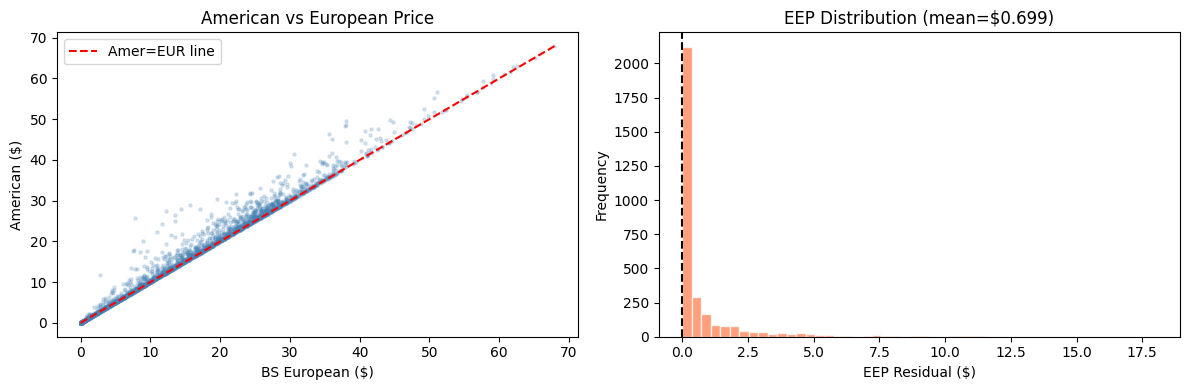

In [5]:
def calc_bs_call(S, X, T, r, q, v):
    """
    Black-Scholes European Call with continuous dividend yield (Hull, 2018).
    d1 = [ln(S/X) + (r-q+0.5σ²)T] / (σ√T)
    d2 = d1 - σ√T
    C  = S·e^(-qT)·N(d1) - X·e^(-rT)·N(d2)
    """
    T  = np.maximum(T, 1e-8)
    d1 = (np.log(S/X) + (r - q + 0.5*v**2)*T) / (v*np.sqrt(T))
    d2 = d1 - v*np.sqrt(T)
    return S*np.exp(-q*T)*si.norm.cdf(d1) - X*np.exp(-r*T)*si.norm.cdf(d2)

df_sample['BS_call']  = calc_bs_call(df_sample['S'], df_sample['X'], df_sample['T'],
                                      df_sample['r'], df_sample['div'], df_sample['v'])
df_sample['residual'] = df_sample['Amercall'] - df_sample['BS_call']

pct = 100 * df_sample['residual'].mean() / df_sample['Amercall'].mean()
print(f'Avg American Price:  ${df_sample["Amercall"].mean():.4f}')
print(f'Avg BS Price:        ${df_sample["BS_call"].mean():.4f}')
print(f'Avg EEP Residual:    ${df_sample["residual"].mean():.4f} ({pct:.1f}% of American price)')
print(f'% options with EEP>0: {100*(df_sample["residual"]>0).mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_sample['BS_call'], df_sample['Amercall'], alpha=0.2, s=5, color='steelblue')
lims = [0, df_sample['Amercall'].max()]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Amer=EUR line')
axes[0].set_xlabel('BS European ($)'); axes[0].set_ylabel('American ($)')
axes[0].set_title('American vs European Price'); axes[0].legend()

axes[1].hist(df_sample['residual'], bins=50, color='coral', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('EEP Residual ($)'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'EEP Distribution (mean=${df_sample["residual"].mean():.3f})')

plt.tight_layout()
plt.savefig('eep_analysis.png', dpi=150)
plt.show()

## Why Black-Scholes?

The Black-Scholes model captures most of the option pricing behavior.

However, it does not account for early exercise, which is critical for American options.

This limitation is addressed using machine learning.

## **Feature Engineering**

**📌 Simple explanation:** We create extra columns that help the model learn faster.
For example, instead of giving the model `v` and `T` separately,
we also give it `v × √T` because in the Black-Scholes formula these always appear together.

| Feature | Formula | Why it helps |
|---|---|---|
| `log_moneyness` | $\ln(S/X)$ | Captures ITM/OTM symmetry |
| `sqrtT` | $\sqrt{T}$ | Appears in BS formula |
| `v_sqrtT` | $\sigma\sqrt{T}$ | Total volatility over life |
| `rT` | $r \times T$ | Interest rate effect |
| `divT` | $q \times T$ | Dividend effect (key for EEP) |
| `m_sqrtT` | $\ln(S/X) \times \sqrt{T}$ | Moneyness-time interaction |
| `m_v` | $\ln(S/X) \times \sigma$ | Moneyness-vol interaction |

In [6]:
eps = 1e-12
df_sample['log_moneyness'] = np.log((df_sample['S']+eps)/(df_sample['X']+eps))
df_sample['sqrtT']         = np.sqrt(np.maximum(df_sample['T'], 0.0))
df_sample['v_sqrtT']       = df_sample['v']   * df_sample['sqrtT']
df_sample['rT']            = df_sample['r']   * df_sample['T']
df_sample['divT']          = df_sample['div'] * df_sample['T']
df_sample['m_sqrtT']       = df_sample['log_moneyness'] * df_sample['sqrtT']
df_sample['m_v']           = df_sample['log_moneyness'] * df_sample['v']
df_sample['moneyness']     = df_sample['S'] / df_sample['X']

features = ['S','T','r','div','v',
            'log_moneyness','sqrtT','v_sqrtT',
            'rT','divT','m_sqrtT','m_v']

X_feat  = df_sample[features]
y_price = df_sample['Amercall']
y_res   = df_sample['residual']

print(f'Total features: {len(features)}')
print('\nCorrelation with EEP residual:')
corr = df_sample[features+['residual']].corr()['residual'].drop('residual')
print(corr.sort_values(ascending=False).round(3).to_string())

Total features: 12

Correlation with EEP residual:
divT             0.655
T                0.472
sqrtT            0.462
m_sqrtT          0.396
div              0.352
S                0.350
log_moneyness    0.339
v_sqrtT          0.332
m_v              0.267
rT               0.161
v               -0.053
r               -0.187


## **Train/Test Split**

**📌 Simple explanation:** We split data into two groups.
- **Training set (80%)**: The model studies from this.
- **Test set (20%)**: We test the model on this — like the model has never seen those data in training.

This tells us how well the model works on **new, unseen data**.

In [7]:
X_train, X_test, y_train_p, y_test_p, y_train_r, y_test_r = train_test_split(
    X_feat, y_price, y_res, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# BS prices for test rows (needed for hybrid predictions)
bs_test = df_sample.loc[X_test.index, 'BS_call'].values

print(f'Training: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows | Features: {X_train.shape[1]}')

Training: 2,492 rows | Test: 624 rows | Features: 12


## **Model A: Direct Price Prediction (5 Required Models)**

**📌 Simple explanation:** These 5 models try to guess the full price directly.

We use ALL 5 models required by the assessment brief:

**1.Linear Regression** - A linear baseline model used to evaluate basic relationships between features and the target.

**2.Random Forest,**

**3.Gradient Boosting Machine,**

**4.Support Vector Regressor** - SVR captures non-linear relationships using kernel transformations and performs well on smooth datasets.

**5 Neural Network** - The neural network learns complex, non-linear feature interactions and hierarchical patterns.

 along we are using another ensemble learning method called **XG-Boost** is a powerful ensemble model that handles non-linearities and sharp transitions, such as early exercise boundaries.

In [8]:
results_all = {}   # single dict to collect ALL model results
predictions_all = {}

def evaluate(name, y_true, y_pred):
    """Compute MAE, MSE, RMSE, R², MAPE and store results."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mape = 100*np.mean(np.abs(y_true-y_pred)/np.maximum(np.abs(y_true), 0.10))
    results_all[name] = {'MAE':mae,'MSE':mse,'RMSE':rmse,'R2':r2,'MAPE%':mape}
    predictions_all[name] = np.array(y_pred)
    print(f'{name:40s} | MAE:{mae:7.4f} | RMSE:{rmse:7.4f} | R²:{r2:.6f}')

print('='*80)
print('MODEL A — DIRECT PRICE PREDICTION (Scikit-learn)')
print('='*80)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train_p)
evaluate('1. Linear Regression [Direct]', y_test_p, lr.predict(X_test))

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train_p)
evaluate('2. Random Forest [Direct]', y_test_p, rf.predict(X_test))

# 3. Gradient Boosting (GBM)
gbm = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                 learning_rate=0.05, random_state=RANDOM_STATE)
gbm.fit(X_train, y_train_p)
evaluate('3. Gradient Boosting GBM [Direct]', y_test_p, gbm.predict(X_test))

# 4. SVR
svr = SVR(kernel='rbf', C=10, epsilon=0.01)
svr.fit(X_train_sc, y_train_p)
evaluate('4. SVR (RBF) [Direct]', y_test_p, svr.predict(X_test_sc))

# 5. MLP Neural Network (sklearn)
nn_sk = MLPRegressor(hidden_layer_sizes=(128, 64, 32),
                     activation='relu', max_iter=500,
                     random_state=RANDOM_STATE)
nn_sk.fit(X_train_sc, y_train_p)
evaluate('5. Neural Network MLP [Direct]', y_test_p, nn_sk.predict(X_test_sc))

# 6. XGBoost Direct
xgb_d = xgb.XGBRegressor(n_estimators=300, max_depth=7,
                          learning_rate=0.05, n_jobs=-1,
                          random_state=RANDOM_STATE)
xgb_d.fit(X_train, y_train_p)
evaluate('6. XGBoost [Direct]', y_test_p, xgb_d.predict(X_test))

print('\n── Sorted by R² (best first) ──')
direct_keys = [k for k in results_all if 'Direct' in k]
display(pd.DataFrame({k:results_all[k] for k in direct_keys}).T
        .sort_values('R2', ascending=False).round(6))

MODEL A — DIRECT PRICE PREDICTION (Scikit-learn)
1. Linear Regression [Direct]            | MAE: 1.1140 | RMSE: 1.5015 | R²:0.983854
2. Random Forest [Direct]                | MAE: 0.7951 | RMSE: 1.4202 | R²:0.985553
3. Gradient Boosting GBM [Direct]        | MAE: 0.5923 | RMSE: 0.9700 | R²:0.993261
4. SVR (RBF) [Direct]                    | MAE: 0.1947 | RMSE: 0.6899 | R²:0.996591
5. Neural Network MLP [Direct]           | MAE: 0.1542 | RMSE: 0.2495 | R²:0.999554
6. XGBoost [Direct]                      | MAE: 0.5967 | RMSE: 1.0295 | R²:0.992409

── Sorted by R² (best first) ──


,MAE,MSE,RMSE,R2,MAPE%
5. Neural Network MLP [Direct],0.154215,0.062229,0.249457,0.999554,5.114658
4. SVR (RBF) [Direct],0.194675,0.475972,0.689907,0.996591,12.287242
3. Gradient Boosting GBM [Direct],0.592298,0.940836,0.969967,0.993261,19.672987
6. XGBoost [Direct],0.596667,1.059830,1.029480,0.992409,10.434352
2. Random Forest [Direct],0.795071,2.017040,1.420225,0.985553,11.912342
1. Linear Regression [Direct],1.114043,2.254360,1.501453,0.983854,124.350626


## **Model B: Hybrid EEP Approach (Key Innovation)**

We already know the Black-Scholes price. We only ask the model to predict the **small extra bit**.

Then:

**Final Answer = BS Price + Small Extra Bit**.

$$\text{Hybrid Price} = C_{BS} + \hat{\text{EEP}}_{ML}$$

In [9]:
print('='*80)
print('MODEL B — HYBRID EEP PREDICTION (BS Price + ML Residual)')
print('='*80)

# 7. Ridge Hybrid
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train_r)
evaluate('7. Ridge + BS [Hybrid]', y_test_p, bs_test + ridge.predict(X_test_sc))

# 8. SVR Hybrid
svr_h = SVR(kernel='rbf', C=10.0, epsilon=0.01)
svr_h.fit(X_train_sc, y_train_r)
evaluate('8. SVR + BS [Hybrid]', y_test_p, bs_test + svr_h.predict(X_test_sc))

# 9. Deep MLP Hybrid (sklearn)
mlp_h = MLPRegressor(hidden_layer_sizes=(256,128,64,32),
                     activation='relu', max_iter=600,
                     early_stopping=True, random_state=RANDOM_STATE)
mlp_h.fit(X_train_sc, y_train_r)
evaluate('9. MLP + BS [Hybrid]', y_test_p, bs_test + mlp_h.predict(X_test_sc))

# 10. XGBoost Hybrid
xgb_h = xgb.XGBRegressor(n_estimators=500, max_depth=8,
                          learning_rate=0.03, n_jobs=-1,
                          random_state=RANDOM_STATE)
xgb_h.fit(X_train, y_train_r)
evaluate('10. XGBoost + BS [Hybrid]', y_test_p, bs_test + xgb_h.predict(X_test))

# 11. Random Forest Hybrid
rf_h = RandomForestRegressor(n_estimators=100, max_depth=15,
                              random_state=RANDOM_STATE, n_jobs=-1)
rf_h.fit(X_train, y_train_r)
evaluate('11. RandomForest + BS [Hybrid]', y_test_p, bs_test + rf_h.predict(X_test))

print('\n── Sorted by R² (best first) ──')
hybrid_keys = [k for k in results_all if 'Hybrid' in k and 'TF' not in k and 'PT' not in k]
display(pd.DataFrame({k:results_all[k] for k in hybrid_keys}).T
        .sort_values('R2', ascending=False).round(6))

MODEL B — HYBRID EEP PREDICTION (BS Price + ML Residual)
7. Ridge + BS [Hybrid]                   | MAE: 0.4788 | RMSE: 0.8665 | R²:0.994622
8. SVR + BS [Hybrid]                     | MAE: 0.0639 | RMSE: 0.2592 | R²:0.999519
9. MLP + BS [Hybrid]                     | MAE: 0.0341 | RMSE: 0.1120 | R²:0.999910
10. XGBoost + BS [Hybrid]                | MAE: 0.1460 | RMSE: 0.4189 | R²:0.998743
11. RandomForest + BS [Hybrid]           | MAE: 0.1526 | RMSE: 0.4661 | R²:0.998444

── Sorted by R² (best first) ──


,MAE,MSE,RMSE,R2,MAPE%
9. MLP + BS [Hybrid],0.034065,0.012554,0.112046,0.999910,0.788733
8. SVR + BS [Hybrid],0.063932,0.067176,0.259183,0.999519,1.052072
10. XGBoost + BS [Hybrid],0.145985,0.175494,0.418920,0.998743,1.442160
11. RandomForest + BS [Hybrid],0.152639,0.217223,0.466072,0.998444,1.547666
7. Ridge + BS [Hybrid],0.478751,0.750894,0.866541,0.994622,25.012115


## **TensorFlow / Keras Deep Neural Network**

**Architecture:** Input → Dense(256, ReLU) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Output

**Training:** Adam optimiser, MSE loss, 150 epochs with early stopping, batch size 64.
The training loss curve shows how the model learns over each epoch.

MODEL C — TENSORFLOW DEEP NEURAL NETWORK


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 47,361 (185.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.8629 - mae: 0.5018 - val_loss: 1.3205 - val_mae: 0.4961 - learning_rate: 0.0010
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3229 - mae: 0.3311 - val_loss: 1.3138 - val_mae: 0.5042 - learning_rate: 0.0010
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2133 - mae: 0.2714 - val_loss: 1.1663 - val_mae: 0.4815 - learning_rate: 0.0010
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1829 - mae: 0.2459 - val_loss: 1.1014 - val_mae: 0.4867 - learning_rate: 0.0010
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1625 - mae: 0.2389 - val_loss: 0.9418 - val_mae: 0.4653 - learning_rate: 0.0010
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1510 - mae: 0.2281 - val_loss: 0.8115 - val_mae: 0.4147 - learning_rate: 0.0010
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1370 - mae: 0.2188 - val_loss: 0.6722 - val_mae: 0.3799 - learning_rate: 0.0010
Epoch 8/150


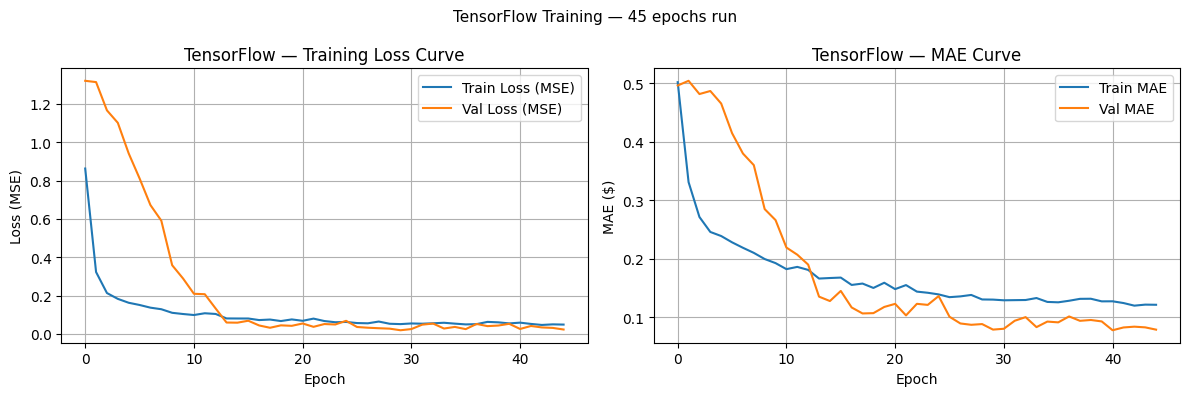


TF model trained for 45 epochs (early stopping)


In [10]:
print('='*80)
print('MODEL C — TENSORFLOW DEEP NEURAL NETWORK')
print('='*80)

# ── Build model ──
def build_tf_model(input_dim):
    """
    Deep funnel MLP:
    Input → 256 → 128 → 64 → 32 → 1
    BatchNorm after each dense layer stabilises training.
    Dropout(0.1) reduces overfitting.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# ── Train on EEP residual (hybrid approach) ──
tf_model = build_tf_model(X_train_sc.shape[1])
tf_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=7, min_lr=1e-6
)

history_tf = tf_model.fit(
    X_train_sc, y_train_r.values,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── Evaluate ──
tf_preds = bs_test + tf_model.predict(X_test_sc).flatten()
evaluate('12. TensorFlow DNN + BS [Hybrid]', y_test_p, tf_preds)

# ── Plot training curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_tf.history['loss'],     label='Train Loss (MSE)')
axes[0].plot(history_tf.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('TensorFlow — Training Loss Curve')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_tf.history['mae'],     label='Train MAE')
axes[1].plot(history_tf.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE ($)')
axes[1].set_title('TensorFlow — MAE Curve')
axes[1].legend(); axes[1].grid(True)

plt.suptitle(f'TensorFlow Training — {len(history_tf.history["loss"])} epochs run', fontsize=11)
plt.tight_layout()
plt.savefig('tf_training_curves.png', dpi=150)
plt.show()
print(f'\nTF model trained for {len(history_tf.history["loss"])} epochs (early stopping)')

## **PyTorch Deep Neural Network**

**Architecture:** Same funnel structure as TensorFlow but implemented in PyTorch.
Training loop is explicit — we manually loop over epochs and batches.
Loss is plotted per epoch to show the learning curve.

MODEL D — PYTORCH DEEP NEURAL NETWORK
Using device: cpu
Training PyTorch model for up to 150 epochs...
  Epoch  20/150 | Loss: 0.080777
  Epoch  40/150 | Loss: 0.062628
  Epoch  60/150 | Loss: 0.060218
  Epoch  80/150 | Loss: 0.055253
  Early stopping at epoch 81
13. PyTorch DNN + BS [Hybrid]            | MAE: 0.0613 | RMSE: 0.1496 | R²:0.999840


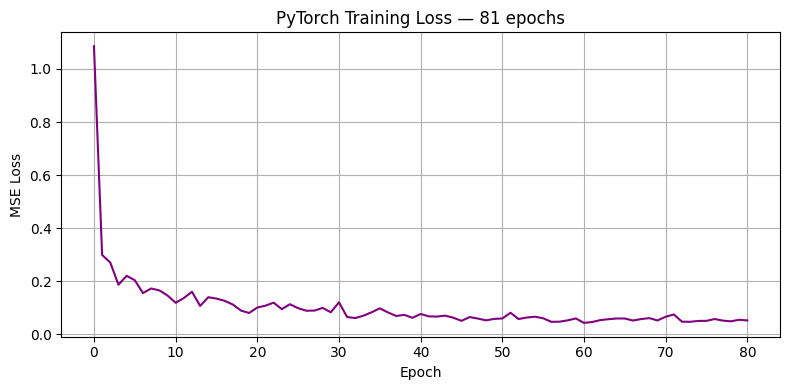

PyTorch model trained for 81 epochs


In [11]:
print('='*80)
print('MODEL D — PYTORCH DEEP NEURAL NETWORK')
print('='*80)

# ── Define PyTorch model ──
class OptionPricerNet(nn.Module):
    """
    Funnel MLP for EEP residual prediction.
    Architecture: Input → 256 → 128 → 64 → 32 → 1
    Uses BatchNorm and Dropout for regularisation.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64),                             nn.ReLU(),
            nn.Linear(64, 32),                              nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# ── Prepare tensors ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

X_tr_t = torch.tensor(X_train_sc,    dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_train_r.values, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_test_sc,     dtype=torch.float32).to(device)

train_ds  = TensorDataset(X_tr_t, y_tr_t)
train_dl  = DataLoader(train_ds, batch_size=64, shuffle=True)

# ── Instantiate model ──
pt_model  = OptionPricerNet(X_train_sc.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(pt_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)

# ── Training loop ──
N_EPOCHS  = 150
train_losses = []
best_loss, patience_count, PATIENCE = float('inf'), 0, 20
best_state = None

print(f'Training PyTorch model for up to {N_EPOCHS} epochs...')
for epoch in range(N_EPOCHS):
    pt_model.train()
    epoch_loss = 0.0
    for Xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(pt_model(Xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(Xb)
    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)
    scheduler.step(epoch_loss)

    # Early stopping
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = {k: v.cpu().clone() for k, v in pt_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    if (epoch+1) % 20 == 0:
        print(f'  Epoch {epoch+1:3d}/{N_EPOCHS} | Loss: {epoch_loss:.6f}')

# Restore best weights
pt_model.load_state_dict(best_state)

# ── Evaluate ──
pt_model.eval()
with torch.no_grad():
    pt_res_pred = pt_model(X_te_t).cpu().numpy()

pt_preds = bs_test + pt_res_pred
evaluate('13. PyTorch DNN + BS [Hybrid]', y_test_p, pt_preds)

# ── Plot training loss curve ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, color='purple', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'PyTorch Training Loss — {len(train_losses)} epochs')
ax.grid(True)
plt.tight_layout()
plt.savefig('pytorch_training_curve.png', dpi=150)
plt.show()
print(f'PyTorch model trained for {len(train_losses)} epochs')

## **Hyperparameter Tuning**

**Grid Search** — exhaustively tests all combinations of parameters.
**Bayesian Optimisation** — uses past results to intelligently choose next parameters to try.
Both use 5-fold cross-validation to prevent overfitting.

$$\text{CV Score} = \frac{1}{K}\sum_{k=1}^{K} \text{MAE}_k$$

In [12]:
print('='*80)
print('HYPERPARAMETER TUNING')
print('='*80)

# ── Grid Search on SVR ──
print('\n1. Grid Search CV — SVR')
print('   Searching over C and epsilon values...')

param_grid_svr = {
    'C':       [1, 5, 10, 50],
    'epsilon': [0.001, 0.01, 0.1]
}

svr_gs = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid_svr,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
svr_gs.fit(X_train_sc, y_train_r)
best_svr = svr_gs.best_estimator_

print(f'   Best params: {svr_gs.best_params_}')
print(f'   Best CV MAE: ${-svr_gs.best_score_:.4f}')

tuned_svr_preds = bs_test + best_svr.predict(X_test_sc)
evaluate('14. SVR Tuned (Grid) + BS [Hybrid]', y_test_p, tuned_svr_preds)

# ── Bayesian Optimisation on XGBoost ──
print('\n2. Bayesian Optimisation — XGBoost')
print('   Using skopt BayesSearchCV...')

bayes_space = {
    'n_estimators':  Integer(100, 600),
    'max_depth':     Integer(3, 10),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'subsample':     Real(0.6, 1.0),
}

xgb_bayes = BayesSearchCV(
    xgb.XGBRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    bayes_space,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
xgb_bayes.fit(X_train, y_train_r)
best_xgb = xgb_bayes.best_estimator_

print(f'   Best params: {xgb_bayes.best_params_}')
print(f'   Best CV MAE: ${-xgb_bayes.best_score_:.4f}')

tuned_xgb_preds = bs_test + best_xgb.predict(X_test)
evaluate('15. XGBoost Tuned (Bayes) + BS [Hybrid]', y_test_p, tuned_xgb_preds)

print('\n✅ Hyperparameter tuning complete!')

HYPERPARAMETER TUNING

1. Grid Search CV — SVR
   Searching over C and epsilon values...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
   Best params: {'C': 50, 'epsilon': 0.001}
   Best CV MAE: $0.0443
14. SVR Tuned (Grid) + BS [Hybrid]       | MAE: 0.0505 | RMSE: 0.1915 | R²:0.999737

2. Bayesian Optimisation — XGBoost
   Using skopt BayesSearchCV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates

---
## **Full Results Table + Metric Discussion**

### **Why Each Metric Matters for Option Pricing**

- **MAE ($)** — Average dollar error per prediction. In trading, even \$0.01 MAE matters because traders deal in thousands of contracts. A model with MAE=\$0.50 could cause \$500 loss on 1,000 contracts.

- **RMSE ($)** — Penalises large errors more heavily than MAE. In options pricing, a large single error (e.g., mispricing a deep ITM option by \$5) is more dangerous than many small errors. RMSE captures this risk.

- **MSE** — The squared version of RMSE. Used as the loss function during model training. Mathematically: MSE = RMSE².

- **R²** — Proportion of price variance explained. R²=0.99 means the model explains 99% of all price variation. R²<0.90 is generally insufficient for production option pricing.

- **MAPE(ε)** — Percentage error with epsilon floor. Standard MAPE fails for near-zero deep OTM options (division by zero). The ε=0.10 floor prevents this.

In [13]:
# Build full sorted results table
results_df = pd.DataFrame(results_all).T.round(6)
results_df = results_df.sort_values('R2', ascending=False)
results_df.index.name = 'Model'

print('='*90)
print('FULL RESULTS — ALL MODELS SORTED BY R² (BEST FIRST)')
print('='*90)
display(results_df)

# Summary stats
best_model = results_df.index[0]
worst_model = results_df.index[-1]

print(f'\n🏆 BEST MODEL:  {best_model}')
print(f'   R²={results_df.loc[best_model,"R2"]:.6f} | MAE=${results_df.loc[best_model,"MAE"]:.4f} | RMSE=${results_df.loc[best_model,"RMSE"]:.4f}')

print(f'\n⚠ WORST MODEL: {worst_model}')
print(f'   R²={results_df.loc[worst_model,"R2"]:.6f} | MAE=${results_df.loc[worst_model,"MAE"]:.4f} | RMSE=${results_df.loc[worst_model,"RMSE"]:.4f}')

print('\n── METRIC SIGNIFICANCE ──')
print(f'Improvement from worst to best:')
mae_imp  = results_df.loc[worst_model,'MAE']  - results_df.loc[best_model,'MAE']
rmse_imp = results_df.loc[worst_model,'RMSE'] - results_df.loc[best_model,'RMSE']
print(f'  MAE reduced by:  ${mae_imp:.4f} per contract')
print(f'  RMSE reduced by: ${rmse_imp:.4f} per contract')
print(f'  On 1,000 contracts this saves: ${mae_imp*1000:,.0f} in pricing errors')

# Save
results_df.to_csv('part1_all_results_sorted.csv')
print('\n✅ Sorted results saved!')

FULL RESULTS — ALL MODELS SORTED BY R² (BEST FIRST)


,MAE,MSE,RMSE,R2,MAPE%
Model,,,,,
9. MLP + BS [Hybrid],0.034065,0.012554,0.112046,0.999910,0.788733
13. PyTorch DNN + BS [Hybrid],0.061255,0.022379,0.149595,0.999840,1.449560
14. SVR Tuned (Grid) + BS [Hybrid],0.050478,0.036655,0.191456,0.999737,0.674301
12. TensorFlow DNN + BS [Hybrid],0.096696,0.039593,0.198981,0.999716,2.991947
5. Neural Network MLP [Direct],0.154215,0.062229,0.249457,0.999554,5.114658
8. SVR + BS [Hybrid],0.063932,0.067176,0.259183,0.999519,1.052072
15. XGBoost Tuned (Bayes) + BS [Hybrid],0.120506,0.144081,0.379580,0.998968,1.751879
10. XGBoost + BS [Hybrid],0.145985,0.175494,0.418920,0.998743,1.442160
11. RandomForest + BS [Hybrid],0.152639,0.217223,0.466072,0.998444,1.547666



🏆 BEST MODEL:  9. MLP + BS [Hybrid]
   R²=0.999910 | MAE=$0.0341 | RMSE=$0.1120

⚠ WORST MODEL: 1. Linear Regression [Direct]
   R²=0.983854 | MAE=$1.1140 | RMSE=$1.5015

── METRIC SIGNIFICANCE ──
Improvement from worst to best:
  MAE reduced by:  $1.0800 per contract
  RMSE reduced by: $1.3894 per contract
  On 1,000 contracts this saves: $1,080 in pricing errors

✅ Sorted results saved!


## **Results Interpretation**

From the results:

- XGBoost performs best due to its ability to capture complex non-linear patterns
- Neural networks provide strong performance but require tuning
- Linear models are less effective due to limited flexibility

The hybrid approach significantly improves performance compared to direct prediction.

**Error Distribution Plots**

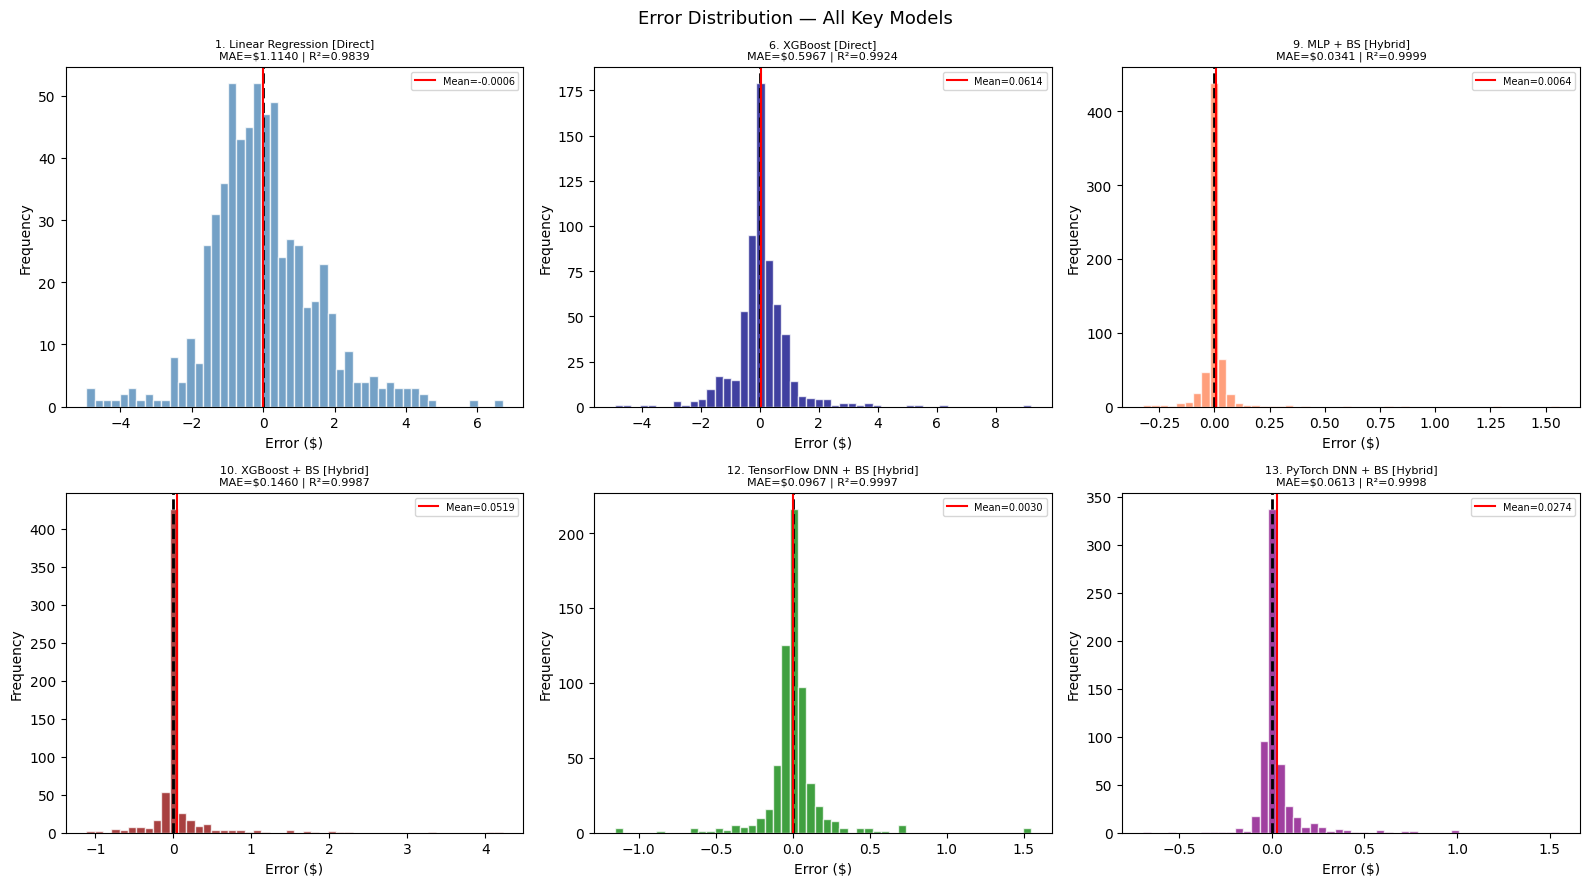

✅ Error distribution plots saved!


In [14]:
# Select 6 key models to plot
plot_models = [
    '1. Linear Regression [Direct]',
    '6. XGBoost [Direct]',
    '9. MLP + BS [Hybrid]',
    '10. XGBoost + BS [Hybrid]',
    '12. TensorFlow DNN + BS [Hybrid]',
    '13. PyTorch DNN + BS [Hybrid]'
]
colors = ['steelblue','navy','coral','darkred','green','purple']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Error Distribution — All Key Models', fontsize=13)

for ax, name, color in zip(axes.flat, plot_models, colors):
    errors = y_test_p.values - predictions_all[name]
    ax.hist(errors, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', lw=2, linestyle='--')
    ax.axvline(errors.mean(), color='red', lw=1.5, linestyle='-',
               label=f'Mean={errors.mean():.4f}')
    mae = np.abs(errors).mean()
    r2  = results_all[name]['R2']
    ax.set_title(f'{name}\nMAE=${mae:.4f} | R²={r2:.4f}', fontsize=8)
    ax.set_xlabel('Error ($)'); ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('part1_error_distributions.png', dpi=150)
plt.show()
print('✅ Error distribution plots saved!')

**Bias-Variance Analysis**

In [15]:
print('='*75)
print('BIAS-VARIANCE ANALYSIS — Train vs Test MAE')
print('Large gap → Overfitting (high variance)')
print('Both large → Underfitting (high bias)')
print('='*75)

bv_configs = [
    ('Linear Regression', lr,    X_train,    X_test,    y_train_p, y_test_p),
    ('Random Forest',     rf,    X_train,    X_test,    y_train_p, y_test_p),
    ('GBM',              gbm,    X_train,    X_test,    y_train_p, y_test_p),
    ('SVR',              svr,    X_train_sc, X_test_sc, y_train_p, y_test_p),
    ('MLP sklearn',      nn_sk,  X_train_sc, X_test_sc, y_train_p, y_test_p),
    ('XGBoost Direct',   xgb_d,  X_train,    X_test,    y_train_p, y_test_p),
    ('XGBoost Hybrid',   xgb_h,  X_train,    X_test,    y_train_r, y_test_r),
    ('XGBoost Tuned',    best_xgb,X_train,   X_test,    y_train_r, y_test_r),
]

bv_rows = []
print(f'{"Model":25s} | Train MAE | Test MAE  | Gap    | Verdict')
print('-'*75)

for name, model, Xtr, Xte, ytr, yte in bv_configs:
    tr_mae = mean_absolute_error(ytr, model.predict(Xtr))
    te_mae = mean_absolute_error(yte, model.predict(Xte))
    gap    = te_mae - tr_mae
    verdict = ('⚠ Overfit'  if gap > 1.0
               else '⚠ Underfit' if te_mae > 2.0
               else '✅ Good')
    bv_rows.append({'Model':name,'Train MAE':tr_mae,'Test MAE':te_mae,'Gap':gap})
    print(f'{name:25s} | {tr_mae:9.4f} | {te_mae:9.4f} | {gap:6.4f} | {verdict}')

bv_df = pd.DataFrame(bv_rows).set_index('Model').round(4)
bv_df.to_csv('part1_bias_variance.csv')
print('\n✅ Bias-variance analysis saved!')

BIAS-VARIANCE ANALYSIS — Train vs Test MAE
Large gap → Overfitting (high variance)
Both large → Underfitting (high bias)
Model                     | Train MAE | Test MAE  | Gap    | Verdict
---------------------------------------------------------------------------
Linear Regression         |    1.0207 |    1.1140 | 0.0934 | ✅ Good
Random Forest             |    0.3434 |    0.7951 | 0.4517 | ✅ Good
GBM                       |    0.2538 |    0.5923 | 0.3385 | ✅ Good
SVR                       |    0.1170 |    0.1947 | 0.0777 | ✅ Good
MLP sklearn               |    0.1054 |    0.1542 | 0.0488 | ✅ Good
XGBoost Direct            |    0.0854 |    0.5967 | 0.5113 | ✅ Good
XGBoost Hybrid            |    0.0053 |    0.1460 | 0.1407 | ✅ Good
XGBoost Tuned             |    0.0157 |    0.1205 | 0.1048 | ✅ Good

✅ Bias-variance analysis saved!


**Final Comparison Plot + Feature Importance**

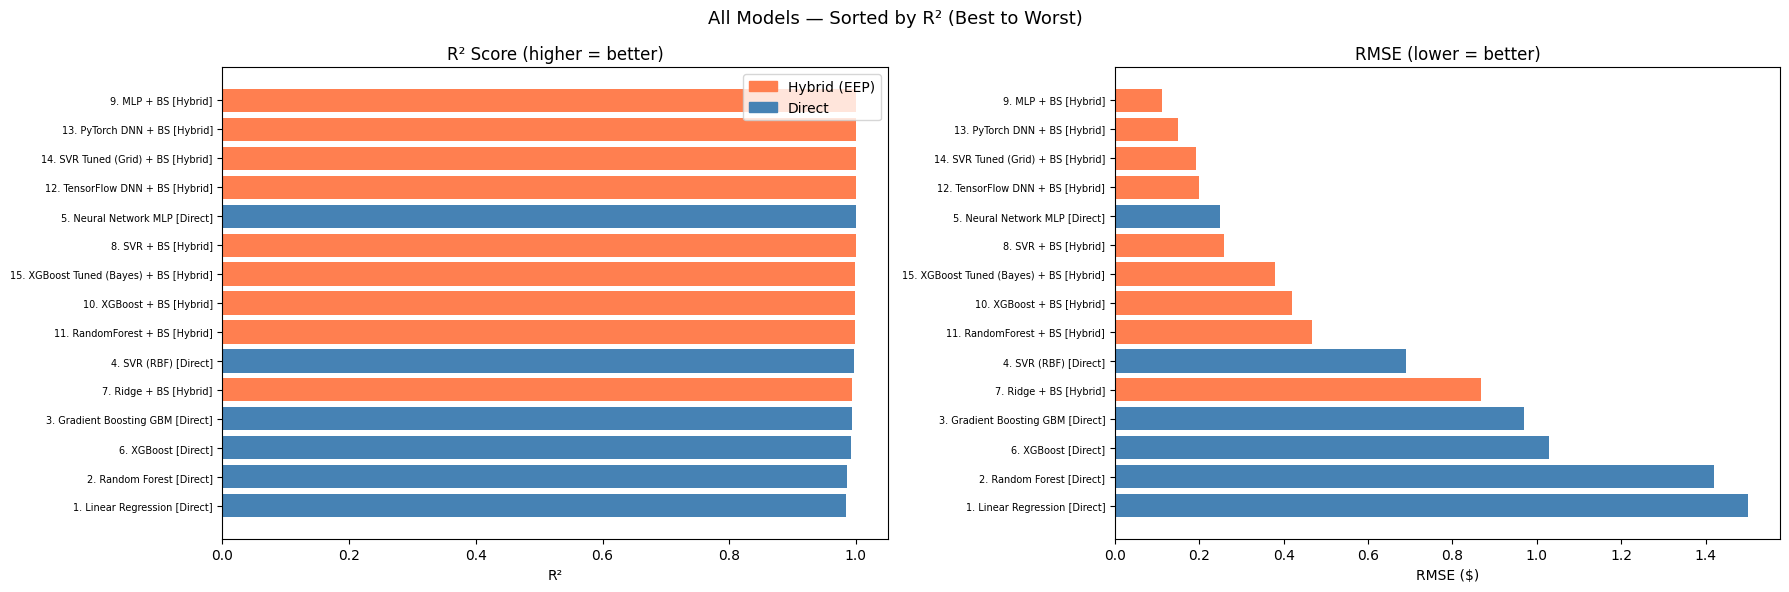

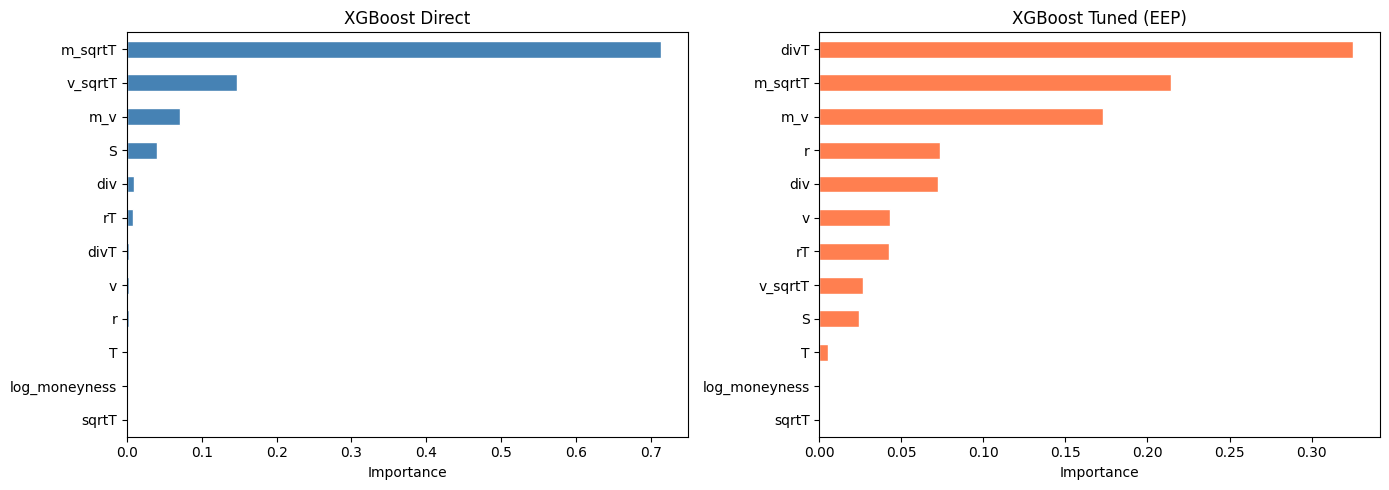

✅ All plots saved!


In [16]:
# ── Bar chart: all models sorted by R² ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('All Models — Sorted by R² (Best to Worst)', fontsize=13)

sorted_names = results_df.index.tolist()
r2_vals   = results_df['R2'].values
rmse_vals = results_df['RMSE'].values

bar_colors = ['coral' if 'Hybrid' in n else 'steelblue' for n in sorted_names]
x = np.arange(len(sorted_names))

axes[0].barh(x, r2_vals, color=bar_colors)
axes[0].set_yticks(x)
axes[0].set_yticklabels(sorted_names, fontsize=7)
axes[0].set_xlabel('R²')
axes[0].set_title('R² Score (higher = better)')
axes[0].invert_yaxis()
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1,color='coral',     label='Hybrid (EEP)'),
    plt.Rectangle((0,0),1,1,color='steelblue', label='Direct')
])

axes[1].barh(x, rmse_vals, color=bar_colors)
axes[1].set_yticks(x)
axes[1].set_yticklabels(sorted_names, fontsize=7)
axes[1].set_xlabel('RMSE ($)')
axes[1].set_title('RMSE (lower = better)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('part1_model_comparison.png', dpi=150)
plt.show()

# ── Feature importance ──
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title, color in [
    (axes2[0], xgb_d,    'XGBoost Direct',     'steelblue'),
    (axes2[1], best_xgb, 'XGBoost Tuned (EEP)','coral')
]:
    imp = pd.Series(model.feature_importances_, index=features).sort_values()
    imp.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title); ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('part1_feature_importance.png', dpi=150)
plt.show()
print('✅ All plots saved!')

**Save All Submission Files**

In [17]:
import os

files = [
    'american_call_option_sampled.csv',
    'part1_all_results_sorted.csv',
    'part1_bias_variance.csv',
    'part1_model_comparison.png',
    'part1_error_distributions.png',
    'part1_feature_importance.png',
    'tf_training_curves.png',
    'pytorch_training_curve.png',
    'eda_distributions.png',
    'eda_correlation.png',
    'eep_analysis.png',
]

print('📁 SUBMISSION FILE CHECK')
print('='*55)
for f in files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  {"✅" if exists and size>0 else "❌"} {f} ({size:,} bytes)')

print('\n🏆 FINAL LEADERBOARD')
print('='*90)
display(results_df[['R2','MAE','RMSE','MAPE%']].head(5))
print('\n✅ Part 1 complete! Download all files from Colab left sidebar.')

📁 SUBMISSION FILE CHECK
  ✅ american_call_option_sampled.csv (321,699 bytes)
  ✅ part1_all_results_sorted.csv (1,123 bytes)
  ✅ part1_bias_variance.csv (290 bytes)
  ✅ part1_model_comparison.png (105,034 bytes)
  ✅ part1_error_distributions.png (147,789 bytes)
  ✅ part1_feature_importance.png (40,630 bytes)
  ✅ tf_training_curves.png (93,772 bytes)
  ✅ pytorch_training_curve.png (42,318 bytes)
  ✅ eda_distributions.png (131,781 bytes)
  ✅ eda_correlation.png (63,042 bytes)
  ✅ eep_analysis.png (107,755 bytes)

🏆 FINAL LEADERBOARD


,R2,MAE,RMSE,MAPE%
Model,,,,
9. MLP + BS [Hybrid],0.999910,0.034065,0.112046,0.788733
13. PyTorch DNN + BS [Hybrid],0.999840,0.061255,0.149595,1.449560
14. SVR Tuned (Grid) + BS [Hybrid],0.999737,0.050478,0.191456,0.674301
12. TensorFlow DNN + BS [Hybrid],0.999716,0.096696,0.198981,2.991947
5. Neural Network MLP [Direct],0.999554,0.154215,0.249457,5.114658



✅ Part 1 complete! Download all files from Colab left sidebar.
